# compare cd for NSA and KIAS w version 2 of fitting (cog restricted to < 2R90)

In [51]:
from astropy.table import Table, vstack, hstack
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib as mpl

from IPython.display import Image

from color_gradient_functions import pogson_mag_from_flux, extract_cog_data, SGA_cog

from scipy.optimize import curve_fit, minimize

## load tables

In [2]:
DATA_FOLDER = '/pscratch/sd/n/nravi/GV_classification/'

In [3]:
kias = Table.read(DATA_FOLDER + 'NSA_v1_0_1_vflag_Portsmouth.fits')

In [ ]:
nsa = Table.read(DATA_FOLDER + 'nsa_v1_0_1_cd_0_5831.fits')
for i in tqdm(np.arange(5831, 641410, 5831)):

    tmp_table = Table.read(DATA_FOLDER + 'nsa_v1_0_1_cd_' + str(i) + '_' + str(i+5831) + '.fits')
    nsa = vstack([nsa, tmp_table])

  5%|▍         | 5/109 [00:02<00:51,  2.04it/s]

## save nsa table

In [5]:
nsa.write(DATA_FOLDER + 'nsa_v1_0_1_cd_v2.fits')

In [15]:
nsa = Table.read(DATA_FOLDER + 'nsa_v1_0_1_cd_v2.fits')

In [16]:
nsa_dict = {}
for i in range(len(nsa)):

    nsa_dict[nsa['IAUNAME'][i]] = i

In [17]:
nsa['kias_cd'] = np.ones(len(nsa))**np.nan

In [18]:
for i in tqdm(range(len(kias))):

    iauname = kias['IAUNAME'][i]
    i_nsa = nsa_dict[iauname]

    nsa['kias_cd'][i_nsa] = kias['cd'][i]

100%|██████████| 641409/641409 [00:03<00:00, 171242.15it/s]


## compare cd values

Text(0, 0.5, 'KIAS $\\Delta (g-i)$')

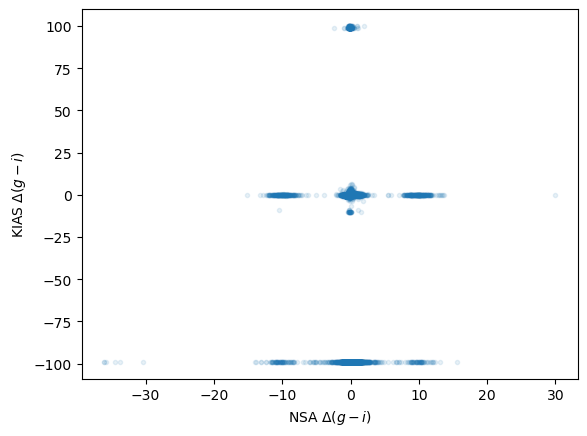

In [19]:
plt.scatter(nsa['NSA_cd'], nsa['kias_cd'], 
          alpha=0.1, marker='.', )
           # bins=100, 
           #range=[[-1, 1], [-5, 5]], 
           # norm=mpl.colors.LogNorm())
plt.xlabel(r'NSA $\Delta (g-i)$')
plt.ylabel(r'KIAS $\Delta (g-i)$')

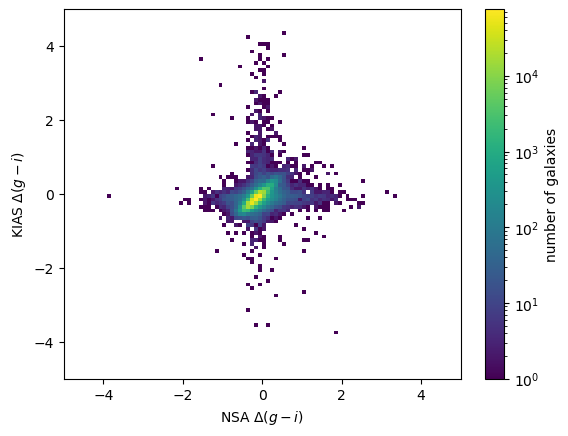

In [20]:
plt.hist2d(nsa['NSA_cd'], nsa['kias_cd'], 
          # alpha=0.1, marker='.', 
           bins=100, 
           range=[[-5, 5], [-5, 5]], 
           norm=mpl.colors.LogNorm())
plt.xlabel(r'NSA $\Delta (g-i)$')
plt.ylabel(r'KIAS $\Delta (g-i)$')
# plt.plot([-1,1],[-1,1], color='r', linewidth=2)
plt.colorbar(label='number of galaxies')

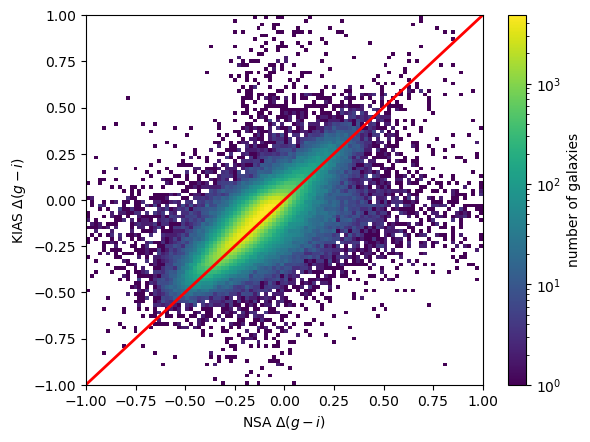

In [21]:
plt.hist2d(nsa['NSA_cd'], nsa['kias_cd'], 
          # alpha=0.1, marker='.', 
           bins=100, 
           range=[[-1, 1], [-1, 1]], 
           norm=mpl.colors.LogNorm())
plt.xlabel(r'NSA $\Delta (g-i)$')
plt.ylabel(r'KIAS $\Delta (g-i)$')
plt.plot([-1,1],[-1,1], color='r', linewidth=2)
plt.colorbar(label='number of galaxies')

(array([0.00000e+00, 1.00000e+00, 2.00000e+00, 2.00000e+00, 4.00000e+00,
        1.00000e+00, 1.00000e+00, 1.00000e+00, 0.00000e+00, 2.00000e+00,
        2.00000e+00, 2.00000e+00, 3.00000e+00, 2.00000e+00, 4.00000e+00,
        3.00000e+00, 4.00000e+00, 5.00000e+00, 6.00000e+00, 4.00000e+00,
        3.00000e+00, 3.00000e+00, 5.00000e+00, 8.00000e+00, 1.20000e+01,
        1.40000e+01, 1.50000e+01, 1.90000e+01, 2.50000e+01, 2.80000e+01,
        3.30000e+01, 3.80000e+01, 4.70000e+01, 6.80000e+01, 9.10000e+01,
        1.17000e+02, 1.54000e+02, 2.07000e+02, 3.08000e+02, 5.62000e+02,
        1.14000e+03, 3.00300e+03, 8.46400e+03, 2.26160e+04, 4.82100e+04,
        7.92730e+04, 1.03780e+05, 1.13787e+05, 9.72980e+04, 5.03490e+04,
        2.08500e+04, 1.07840e+04, 6.36100e+03, 3.64100e+03, 2.13500e+03,
        1.27700e+03, 8.03000e+02, 5.97000e+02, 4.06000e+02, 2.55000e+02,
        2.30000e+02, 1.62000e+02, 1.33000e+02, 1.13000e+02, 1.06000e+02,
        8.00000e+01, 7.20000e+01, 7.10000e+01, 5.40

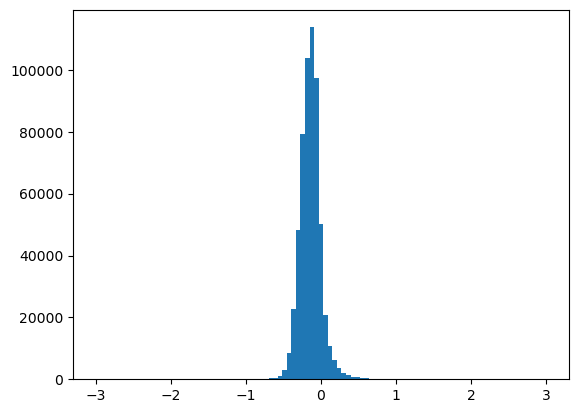

In [22]:
plt.hist(nsa['NSA_cd'], bins=np.linspace(-3,3,100))

In [23]:
nsa_highcd = nsa[nsa['NSA_cd'] > 2]
nsa_highcd[:5]

IAUNAME,SUBDIR,RA,DEC,ISDSS,INED,ISIXDF,IALFALFA,IZCAT,ITWODF,MAG,Z,ZSRC,SIZE,RUN,CAMCOL,FIELD,RERUN,XPOS,YPOS,NSAID,ZDIST,SERSIC_NMGY,SERSIC_NMGY_IVAR,SERSIC_OK,SERSIC_RNMGY,SERSIC_ABSMAG,SERSIC_AMIVAR,EXTINCTION,SERSIC_KCORRECT,SERSIC_KCOEFF,SERSIC_MTOL,SERSIC_B300,SERSIC_B1000,SERSIC_METS,SERSIC_MASS,XCEN,YCEN,NPROF,PROFMEAN,PROFMEAN_IVAR,QSTOKES,USTOKES,BASTOKES,PHISTOKES,PETRO_FLUX,PETRO_FLUX_IVAR,FIBER_FLUX,FIBER_FLUX_IVAR,PETRO_BA50,PETRO_PHI50,PETRO_BA90,PETRO_PHI90,SERSIC_FLUX,SERSIC_FLUX_IVAR,SERSIC_N,SERSIC_BA,SERSIC_PHI,ASYMMETRY,CLUMPY,DFLAGS,AID,PID,DVERSION,PROFTHETA,PETRO_THETA,PETRO_TH50,PETRO_TH90,SERSIC_TH50,PLATE,FIBERID,MJD,RACAT,DECCAT,ZSDSSLINE,SURVEY,PROGRAMNAME,PLATEQUALITY,TILE,PLUG_RA,PLUG_DEC,ELPETRO_BA,ELPETRO_PHI,ELPETRO_FLUX_R,ELPETRO_FLUX_IVAR_R,ELPETRO_THETA_R,ELPETRO_TH50_R,ELPETRO_TH90_R,ELPETRO_THETA,ELPETRO_FLUX,ELPETRO_FLUX_IVAR,ELPETRO_TH50,ELPETRO_TH90,ELPETRO_APCORR_R,ELPETRO_APCORR,ELPETRO_APCORR_SELF,ELPETRO_NMGY,ELPETRO_NMGY_IVAR,ELPETRO_OK,ELPETRO_RNMGY,ELPETRO_ABSMAG,ELPETRO_AMIVAR,ELPETRO_KCORRECT,ELPETRO_KCOEFF,ELPETRO_MASS,ELPETRO_MTOL,ELPETRO_B300,ELPETRO_B1000,ELPETRO_METS,IN_DR7_LSS,g_mtot,g_m0,g_a1,g_a2,i_mtot,i_m0,i_a1,i_a2,NSA_cd,g_mtot_err,g_m0_err,g_a1_err,g_a2_err,i_mtot_err,i_m0_err,i_a1_err,i_a2_err,kias_cd
bytes19,bytes27,float64,float64,int32,int32,int32,int32,int32,int32,float32,float32,bytes7,float32,int16,uint8,int16,bytes3,float32,float32,int32,float32,float32[7],float32[7],int16,float32[7],float32[7],float32[7],float32[7],float32[7],float32[5],float32[7],float32,float32,float32,float32,float64,float64,uint8[7],"float32[15,7]","float32[15,7]","float32[15,7]","float32[15,7]","float32[15,7]","float32[15,7]",float32[7],float32[7],float32[7],float32[7],float32,float32,float32,float32,float32[7],float32[7],float32,float32,float32,float32[7],float32[7],int32[7],int32,int32,bytes8,float32[15],float32,float32,float32,float32,int32,int16,int32,float64,float64,float32,bytes6,bytes27,bytes8,int32,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32[7],float32[7],float32[7],float32[7],float32,float32[7],float32[7],float32[7],float32[7],int16,float32[7],float32[7],float32[7],float32[7],float32[5],float32,float32[7],float32,float32,float32,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
J102921.56+003732.9,10h/p00/J102921.56+003732.9,157.33985429476124,0.6258299745452932,2620,-1,-1,-1,194253,124155,16.67723,0.0974411,sdss,0.04766258,756,5,277,301,37.48001,1068.5017,2619,0.09681678,5.681574 .. 841.9788,4.1074557 .. 0.0017694114,1,6.127161 .. 837.1161,-16.842861 .. -22.336853,112.47644 .. 1064.1,0.5881355 .. 0.10492791,-0.00910887 .. 0.057804096,2.549364e-05 .. 1.1286724e-06,0.00030291904 .. 1.1316959,0.0052219145,0.14995441,0.02815376,61625610000.0,177.41696166992188,126.52364349365234,9 .. 11,0.004438006 .. 0.0,14418.615 .. 0.0,-0.7976378 .. 0.03192215,-0.0017056459 .. -0.4156505,0.11257002 .. 0.41155759,-89.93874 .. -42.804142,4.708963 .. 600.6672,11.657257 .. 0.017441927,0.13919248 .. 138.87498,573.46716 .. 0.9078785,0.89813715,41.748352,0.7435155,46.025757,3.3053274 .. 793.10376,14.799517 .. 0.04713359,3.4062443,0.6140198,44.62671,-0.042832017 .. -0.042279936,0.1736403 .. 0.0008508563,0 .. 0,0,32,v2_1_13,0.22341923 .. 258.39,7.549587,3.4387972,9.42301,4.9121227,272,625,51941,157.3398451602364,0.6258273737612537,0.0,sdss,legacy,good,116,157.33983,0.62584912,0.7435155,46.025757,304.97742,0.6696404,8.448299,3.8146207,10.12002,8.448299,5.736146 .. 623.94305,10.337998 .. 0.018633738,8.119269 .. 3.7242153,14.524134 .. 11.252756,0.99917537,1.0648042 .. 1.0029444,1.0652351 .. 1.0039879,9.859942 .. 662.3936,2.3937209 .. 0.0025286376,1,10.116799 .. 658.03705,-17.413557 .. -22.064783,197.41202 .. 941.1745,-0.036925472 .. 0.046196595,1.7987597e-05 .. 8.5865594e-07,42641510000.0,0.0001302389 .. 1.006884,0.005803871,0.17156687,0.028312722,0.0,17.7373

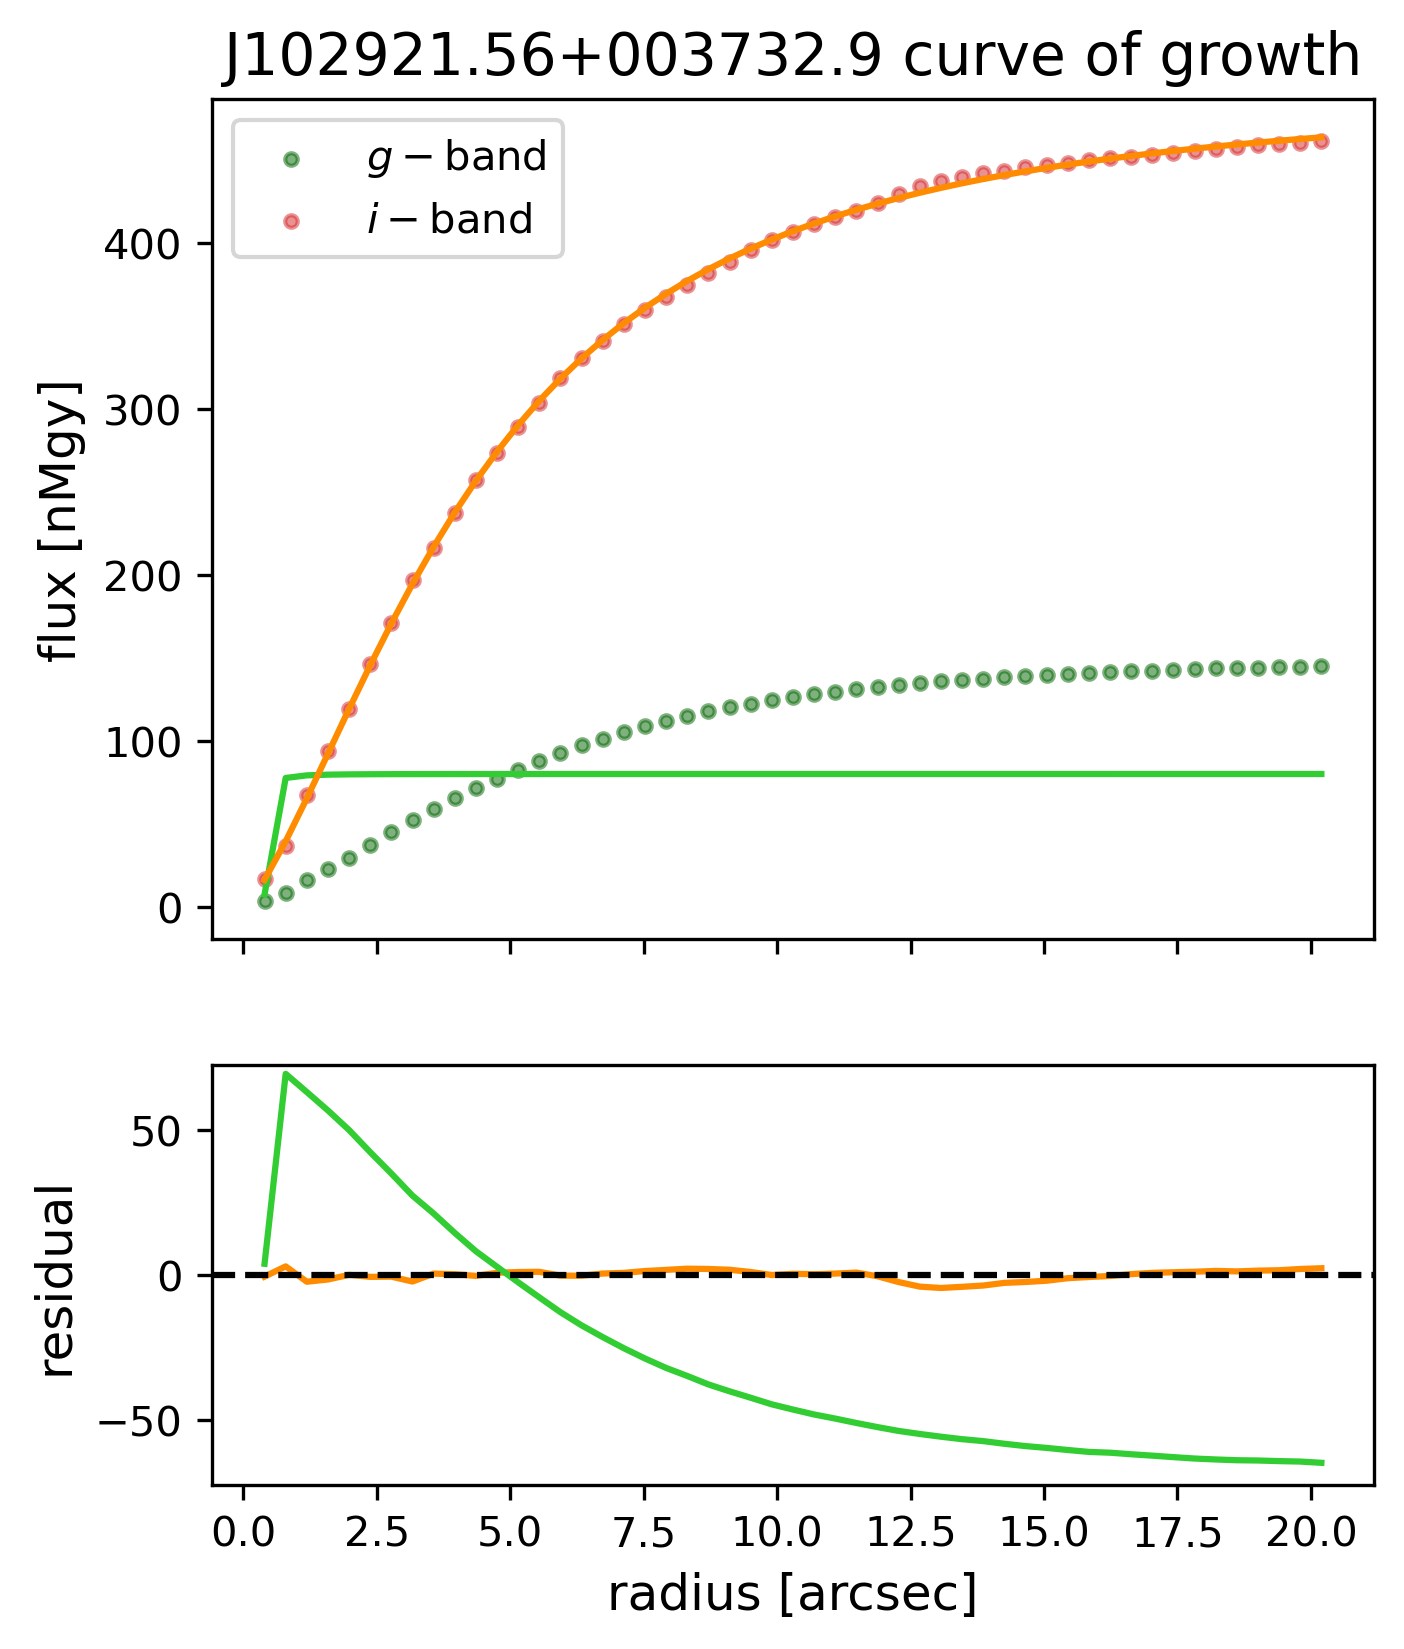

In [24]:
Image(DATA_FOLDER + '/cog_plots/' + str(nsa_highcd['IAUNAME'][0]) + '.png')

(-5.0, 5.0)

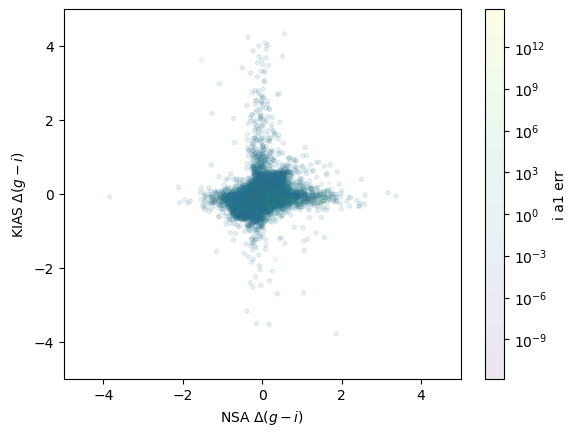

In [28]:
plt.scatter(nsa['NSA_cd'], nsa['kias_cd'], 
          alpha=0.1, marker='.', 
           # bins=100, 
           # range=[[-5, 5], [-5, 5]], 
            c=nsa['i_a1_err'],
           norm=mpl.colors.LogNorm())
plt.xlabel(r'NSA $\Delta (g-i)$')
plt.ylabel(r'KIAS $\Delta (g-i)$')
# plt.plot([-1,1],[-1,1], color='r', linewidth=2)
plt.colorbar(label='i a1 err')
plt.xlim(-5,5)
plt.ylim(-5,5)

(-2.0, 2.0)

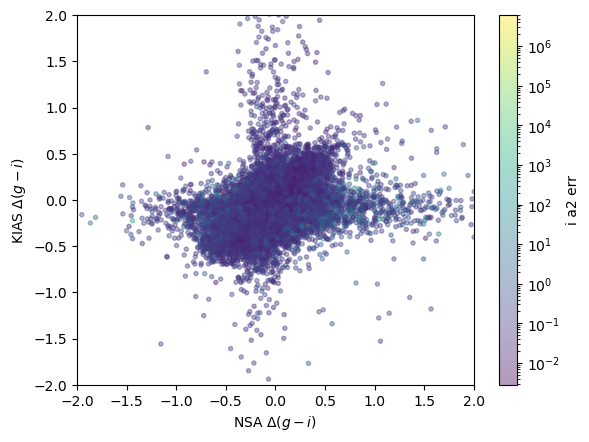

In [33]:
plt.scatter(nsa['NSA_cd'], nsa['kias_cd'], 
          alpha=0.4, marker='.', 
           # bins=100, 
           # range=[[-5, 5], [-5, 5]], 
            c=nsa['i_a2_err'],
           norm=mpl.colors.LogNorm()
           )
plt.xlabel(r'NSA $\Delta (g-i)$')
plt.ylabel(r'KIAS $\Delta (g-i)$')
# plt.plot([-1,1],[-1,1], color='r', linewidth=2)
plt.colorbar(label='i a2 err')
plt.xlim(-2,2)
plt.ylim(-2,2)

(array([4.58529e+05, 9.51330e+04, 2.61050e+04, 1.05020e+04, 5.37600e+03,
        3.18300e+03, 1.97900e+03, 1.31700e+03, 9.66000e+02, 6.56000e+02,
        5.43000e+02, 3.96000e+02, 3.06000e+02, 2.77000e+02, 2.33000e+02,
        2.05000e+02, 1.75000e+02, 1.24000e+02, 1.22000e+02, 1.04000e+02,
        8.10000e+01, 7.60000e+01, 8.30000e+01, 7.20000e+01, 6.30000e+01,
        5.40000e+01, 5.20000e+01, 4.80000e+01, 5.80000e+01, 3.70000e+01,
        4.60000e+01, 3.30000e+01, 4.10000e+01, 2.70000e+01, 2.70000e+01,
        3.30000e+01, 2.80000e+01, 2.50000e+01, 2.70000e+01, 2.10000e+01,
        1.30000e+01, 2.20000e+01, 2.20000e+01, 1.50000e+01, 1.50000e+01,
        1.80000e+01, 1.90000e+01, 1.60000e+01, 1.20000e+01, 1.80000e+01,
        1.90000e+01, 1.60000e+01, 1.50000e+01, 1.00000e+01, 1.20000e+01,
        1.10000e+01, 1.10000e+01, 7.00000e+00, 7.00000e+00, 6.00000e+00,
        6.00000e+00, 1.00000e+01, 4.00000e+00, 1.50000e+01, 5.00000e+00,
        1.00000e+01, 8.00000e+00, 1.00000e+01, 3.00

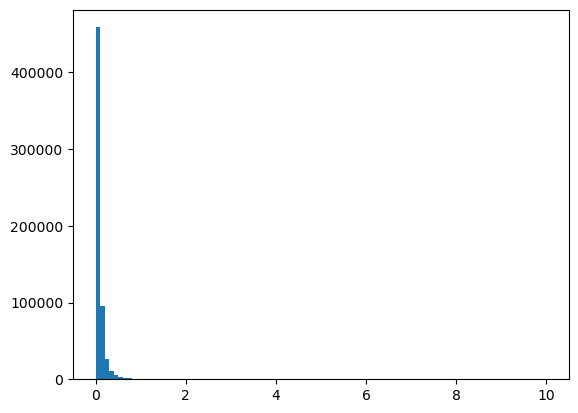

In [36]:
plt.hist(nsa['i_a1_err']/nsa['i_a1'], bins=np.linspace(0,10,100))

(-2.0, 2.0)

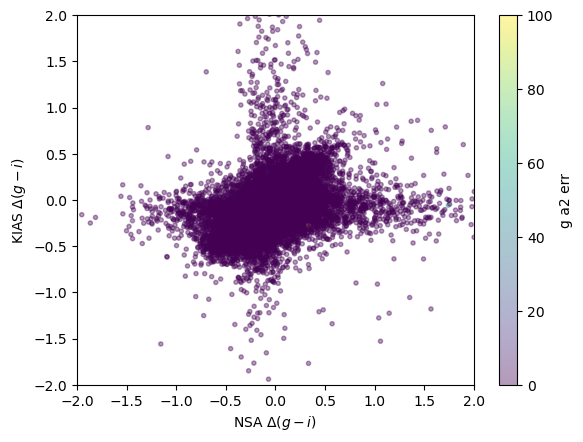

In [40]:
plt.scatter(nsa['NSA_cd'], nsa['kias_cd'], 
          alpha=0.4, marker='.', 
           # bins=100, 
           # range=[[-5, 5], [-5, 5]], 
            c=nsa['g_a2_err']/nsa['g_a2'],
           vmin=0,
            vmax=100
           )
plt.xlabel(r'NSA $\Delta (g-i)$')
plt.ylabel(r'KIAS $\Delta (g-i)$')
# plt.plot([-1,1],[-1,1], color='r', linewidth=2)
plt.colorbar(label='g a2 err')
plt.xlim(-2,2)
plt.ylim(-2,2)

## try to fix this fit

In [44]:
g_r, g_f = extract_cog_data(str(nsa_highcd['IAUNAME'][0]), nsa_highcd['SUBDIR'][0], nsa_highcd['PID'][0], 'g', '/global/cfs/projectdirs/sdss/data/sdss/dr17/sdss/atlas/v1/detect/v1_0/')


In [48]:
R90 = nsa_highcd['ELPETRO_TH90_R'][0]
g_f = g_f[g_r < 2*R90]
g_r = g_r[g_r < 2*R90]

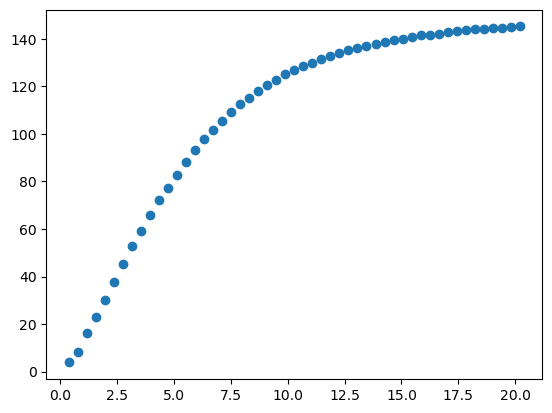

In [49]:
plt.scatter(g_r, g_f)

In [52]:
g_mag = pogson_mag_from_flux(g_f)

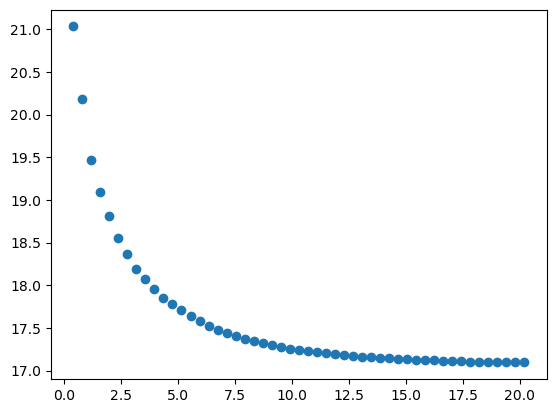

In [53]:
plt.scatter(g_r, g_mag)